# Prepare Sentiment Analysis

In [1]:
# Import Libraries
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
from tqdm import tqdm

In [2]:
# Load dataset
#df = pd.read_csv("dpdr_preprocessed_final.csv")
# Okay decoding didn't work properly again

In [3]:
#import chardet

#with open("dpdr_preprocessed_final.csv", "rb") as f:
#    raw_data = f.read(100000)  # sample
#    result = chardet.detect(raw_data)

#print(result)


In [4]:
df = pd.read_csv("dpdr_topics_sortiert.csv", encoding="utf-8", encoding_errors="replace")

In [5]:
print(df["document"].str.contains(r"Ã|â|�", na=False).sum())

0


In [6]:
# In case decoding does not work
#from ftfy import fix_text

#df["text"] = df["text"].apply(lambda x: fix_text(x) if isinstance(x, str) else x)
#df["title"] = df["title"].apply(lambda x: fix_text(x) if isinstance(x, str) else x)
#df["document"] = df["document"].apply(lambda x: fix_text(x) if isinstance(x, str) else x)

print(df["text"].str.contains(r"Ã|â|�", na=False).sum())
print(df["title"].str.contains(r"Ã|â|�", na=False).sum())
print(df["document"].str.contains(r"Ã|â|�", na=False).sum())
# No more falsely decoded rows

0
0
0


# New Sentiment Analysis

Load the Model and Tokenizer

In [7]:
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print("Using device:", device)
print(model.config.id2label)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using device: cpu
{0: 'negative', 1: 'neutral', 2: 'positive'}


In [8]:
# There is a maximum of tokenizers that can be used per chunk of text. With this code, I split long documents into chunks and then the sentiment score is averaged for the chunks

def get_sentiment_scores(text, max_length=512, stride=256):
    """
    Runs sentiment analysis on one document.
    Long documents are split into overlapping chunks.
    Returns averaged negative, neutral, and positive probabilities.
    """

    if not isinstance(text, str) or text.strip() == "":
        return {
            "negative_prob": None,
            "neutral_prob": None,
            "positive_prob": None,
            "sentiment_label": None
        }

    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length,
        stride=stride,
        return_overflowing_tokens=True,
        padding=True
    )

    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)

    all_probs = []

    with torch.no_grad():
        for i in range(input_ids.shape[0]):
            outputs = model(
                input_ids=input_ids[i].unsqueeze(0),
                attention_mask=attention_mask[i].unsqueeze(0)
            )
            scores = outputs.logits[0].detach().cpu().numpy()
            probs = softmax(scores)
            all_probs.append(probs)

    mean_probs = pd.DataFrame(all_probs).mean(axis=0)

    id2label = model.config.id2label  # e.g. {0: 'negative', 1: 'neutral', 2: 'positive'}
    label_probs = {id2label[i]: float(p) for i, p in enumerate(mean_probs)}

    sentiment_label = max(label_probs, key=label_probs.get)

    return {
        "negative_prob": label_probs.get("negative"),
        "neutral_prob": label_probs.get("neutral"),
        "positive_prob": label_probs.get("positive"),
        "sentiment_label": sentiment_label
    }

Do Sentiment Analysis

In [9]:
results = []

for text in tqdm(df["document"], desc="Running sentiment analysis"):
    result = get_sentiment_scores(text)
    results.append(result)

sentiment_df = pd.DataFrame(results)

df_sentiment = pd.concat([df.reset_index(drop=True), sentiment_df], axis=1)

df_sentiment.head()

Running sentiment analysis: 100%|██████████| 922/922 [10:37<00:00,  1.45it/s]


,Unnamed: 0,date_utc,timestamp,title,text,subreddit,comments,url,document,word_count,topic,probs,negative_prob,neutral_prob,positive_prob,sentiment_label
0,1,2025-12-14,1765741825,Am I too inteligent for life or am i just coping?,"'ve constructed a fake world in my mind, the r...",dpdr,1,https://www.reddit.com/r/dpdr/comments/1pmn69k...,Am I too inteligent for life or am i just copi...,175,1,0.291049,0.721871,0.247036,0.031094,negative
1,2,2025-12-14,1765734691,Childhood depersonalization,Im a 17 female Ive had depersonalization for 1...,dpdr,5,https://www.reddit.com/r/dpdr/comments/1pmk8s1...,Childhood depersonalization Im a 17 female Ive...,64,15,0.104179,0.659415,0.305332,0.035253,negative
2,3,2025-12-14,1765707679,Magnesium glycinate helped,After reading so many people saying it would h...,dpdr,9,https://www.reddit.com/r/dpdr/comments/1pmava7...,Magnesium glycinate helped After reading so ma...,72,5,0.289272,0.012217,0.130026,0.857757,positive
3,4,2025-12-14,1765694746,Dream-like state,I think I'm experiencing it again recentlyEver...,dpdr,2,https://www.reddit.com/r/dpdr/comments/1pm7kyw...,Dream-like state I think I'm experiencing it a...,91,9,1.000000,0.420441,0.500012,0.079547,neutral
4,5,2025-12-14,1765713507,Difficulty To Process Information Properly?,"Hi there,Dissociation makes it incredibly hard...",dpdr,6,https://www.reddit.com/r/dpdr/comments/1pmcez0...,Difficulty To Process Information Properly? Hi...,76,10,1.000000,0.679946,0.303124,0.016929,negative


Further Inspect Posts

In [10]:
df_sentiment[df_sentiment["sentiment_label"] == "positive"].sample(10)

,Unnamed: 0,date_utc,timestamp,title,text,subreddit,comments,url,document,word_count,topic,probs,negative_prob,neutral_prob,positive_prob,sentiment_label
375,810,2026-01-17,1768675139,No one gets it,Im in this place now where i feel a lot better...,dpdr,5,https://www.reddit.com/r/dpdr/comments/1qfl3yf...,No one gets it Im in this place now where i fe...,159,15,0.064932,0.161970,0.263864,0.574166,positive
351,"For any1 that has fully recovered, what does b...",2026-01-01,1767299690,"For any1 that has fully recovered, what does b...",I've been working very hard on getting back in...,dpdr,9,https://www.reddit.com/r/dpdr/comments/1q1ebsc...,"For any1 that has fully recovered, what does b...",113,15,0.043480,0.061852,0.435086,0.503062,positive
503,if anyone want to rant?,2026-01-22,1769074799,if anyone want to rant?,"i havent been on in a while, ive been really p...",dpdr,1,https://www.reddit.com/r/dpdr/comments/1qjqa6d...,if anyone want to rant? i havent been on in a ...,49,15,0.086377,0.075311,0.327439,0.597251,positive
546,Mastering Dpdr,2026-02-04,1770238651,Mastering Dpdr,"Im no longer anxious and still have symptoms, ...",dpdr,3,https://www.reddit.com/r/dpdr/comments/1qw0q51...,Mastering Dpdr Im no longer anxious and still ...,15,14,0.410376,0.017587,0.149085,0.833329,positive
579,Take care of yourself like a loved one.,2026-02-01,1769952209,Take care of yourself like a loved one.,NaN,dpdr,0,https://www.reddit.com/r/dpdr/comments/1qsycs6...,Take care of yourself like a loved one.,8,1,0.484671,0.022593,0.295278,0.682130,positive
362,Medication experience and recommendations please.,2026-01-01,1767268697,Medication experience and recommendations please.,I've been going through dpdr from four years n...,dpdr,13,https://www.reddit.com/r/dpdr/comments/1q12msc...,Medication experience and recommendations plea...,57,5,1.000000,0.007851,0.109267,0.882882,positive
599,DPDR study,2026-01-30,1769771267,DPDR study,"Hey everyone, I hope this can stay, but please...",dpdr,2,https://www.reddit.com/r/dpdr/comments/1qr2jlh...,"DPDR study Hey everyone, I hope this can stay,...",156,9,0.162846,0.008657,0.319844,0.671499,positive
55,60,2025-12-10,1765345028,Lamictal?,Those who have had success with lamictal how d...,dpdr,24,https://www.reddit.com/r/dpdr/comments/1piumdk...,Lamictal? Those who have had success with lami...,13,5,0.350878,0.018905,0.490035,0.491061,positive
215,231,2025-12-28,1766948801,Can anyone else relate?,I had dpdr for the last 5 years and as a resul...,dpdr,0,https://www.reddit.com/r/dpdr/comments/1pxzi9x...,Can anyone else relate? I had dpdr for the las...,115,9,0.171645,0.028149,0.442901,0.528950,positive
142,155,2025-12-18,1766087256,Social anxiety,Had dpdr for very very long. One time I had ab...,dpdr,12,https://www.reddit.com/r/dpdr/comments/1pq09f0...,Social anxiety Had dpdr for very very long. On...,47,15,0.230138,0.032910,0.256366,0.710724,positive


In [11]:
# Give out some topics with positive labels. Are they all positive?
df_sentiment[df_sentiment["sentiment_label"] == "negative"][["title", "text"]].head(10)
#Does not necessarily seem so. Let's inspect this further

,title,text
0,Am I too inteligent for life or am i just coping?,"'ve constructed a fake world in my mind, the r..."
1,Childhood depersonalization,Im a 17 female Ive had depersonalization for 1...
4,Difficulty To Process Information Properly?,"Hi there,Dissociation makes it incredibly hard..."
5,is this normal ?,i got dpdr and i feel like everyone looks so u...
6,Who got DP/DR after an infection ?,Who got DP/DR after an infection like Covid or...
7,Is it ok to cry?,People talk about accepting the feelings which...
9,Constant DPDR at 17,"Hi everyone,In May of this year I had gotten a..."
12,Realizations after stopping SSRI,"I've been on almost every major SSRI known, th..."
13,Strange Eye Sensation Which Correlates With My...,"Hi there,my anxiety manifests in a way that se..."
14,Is that dpdr ?,Constant head pressure on sides and sinuses al...


In [12]:
print(df_sentiment.loc[143, "document"])

Boyfriend has dpdr any help? My boyfriend and I have been together a few months now. He shared with me at the beginning of us dating that he has dpdr and his was triggered from smoking marijuana at a young age for some years. For reference, he is now 33, highly intelligent, successful and just an all around amazing person. From the outside looking in, you could never know his struggles, thats how well he has learned to manage his symptoms. Lately he has been sharing more about it and last night we had a very intense and deep conversation regarding his dpdr. I want to understand as much as possible and find ways to help and support him as his partner. Any help would be greatly appreciated.


In [13]:
for post in df_sentiment[df_sentiment["sentiment_label"] == "negative"]["document"].sample(10):
    print(post)
    print("\n" + "-"*100 + "\n")

My drawing **TRIGGER WARNING** I can't draw for shit hahaha... But I just decided why not... Just get my thoughts and feelings onto paper.. It's my hand reaching out to the world, wanting to feel connected to it again ....and there's some alien antennas coming out of the world because the world feels very alien and unfamiliar to me...

----------------------------------------------------------------------------------------------------

I genuinely can't believe this is how my life turned out to be 8 years of chronic severe nonstop DPDR from deeply complex neurological issues and multiple mental illnesses.It's little to say that I am dead for the last decade. Not only I am dead but I am in hell, pure mental, existential hell of bizzare experiences.I cannot believe in what my life turned into and what I've become.I never even knew states like this were possible. Bizzare dreamlike states for years, time is non-existent, multiple psychosis, severe insomnia, epilepsy, anhedonia, memory is p

Check Sentiment Distribution

In [14]:
df_sentiment["sentiment_label"].value_counts()

sentiment_label
negative    618
neutral     224
positive     80
Name: count, dtype: int64

In [15]:
df_sentiment["sentiment_label"].value_counts(normalize=True) * 100

sentiment_label
negative    67.028200
neutral     24.295011
positive     8.676790
Name: proportion, dtype: float64

Descriptive Statistics for Sentiment Probabilities

In [49]:
sentiment_descriptives = df_sentiment[
    ["negative_prob", "neutral_prob", "positive_prob"]
].describe()

sentiment_descriptives

,negative_prob,neutral_prob,positive_prob
count,922.000000,922.000000,922.000000
mean,0.573677,0.316417,0.109907
std,0.297933,0.212052,0.197206
min,0.002404,0.033420,0.004809
25%,0.331432,0.137981,0.013362
50%,0.664448,0.270494,0.028525
75%,0.835356,0.443619,0.089282
max,0.952889,0.934802,0.958828


In [17]:
# For APA-Style Values
apa_sentiment_descriptives = df_sentiment[
    ["negative_prob", "neutral_prob", "positive_prob"]
].agg(["mean", "std", "min", "max"]).T

apa_sentiment_descriptives

,mean,std,min,max
negative_prob,0.573677,0.297933,0.002404,0.952889
neutral_prob,0.316417,0.212052,0.033420,0.934802
positive_prob,0.109907,0.197206,0.004809,0.958828


Save Results

In [18]:
#df_sentiment.to_excel("reddit_sentiment_results_cardiff_latest.xlsx", index=False)
#df_sentiment.to_csv("reddit_sentiment_results_cardiff_latest.csv", index=False)

#Save Results as list
df_sentiment_results = pd.DataFrame(results)
df_sentiment_results["document"] = df["document"].values

#print("Files saved.")

# Sentiment by Topic

Prepare the Data

In [19]:
# Load the Dataset
#df = pd.read_csv("dpdr_topics_sortiert.csv")

# Does Decoding work?
#print(df["document"].str.contains(r"Ã|â|�", na=False).sum())

In [20]:
merged_df=df_sentiment
#Merge the Data
#merged_df = df.merge(df_sentiment, on="document", how="left")
#Beware that both df_sentiment and sentiment_df exist in this notebook. Only df_sentiment contains the "document" row though

In [21]:
# See if merging worked as expected
#print(f"Total rows: {len(merged_df)}")
#print(f"Unmatched rows: {merged_df['sentiment_label'].isna().sum()}")

In [22]:
merged_df.head(2)

,Unnamed: 0,date_utc,timestamp,title,text,subreddit,comments,url,document,word_count,topic,probs,negative_prob,neutral_prob,positive_prob,sentiment_label
0,1,2025-12-14,1765741825,Am I too inteligent for life or am i just coping?,"'ve constructed a fake world in my mind, the r...",dpdr,1,https://www.reddit.com/r/dpdr/comments/1pmn69k...,Am I too inteligent for life or am i just copi...,175,1,0.291049,0.721871,0.247036,0.031094,negative
1,2,2025-12-14,1765734691,Childhood depersonalization,Im a 17 female Ive had depersonalization for 1...,dpdr,5,https://www.reddit.com/r/dpdr/comments/1pmk8s1...,Childhood depersonalization Im a 17 female Ive...,64,15,0.104179,0.659415,0.305332,0.035253,negative


In [23]:
# Calculate the average sentiment score per topic
topic_sentiment_scores = (
    merged_df
    .groupby("topic")
    .agg(
        n_documents=("sentiment_label", "count"),
        mean_negative=("negative_prob", "mean"),
        sd_negative=("negative_prob", "std"),
        mean_neutral=("neutral_prob", "mean"),
        sd_neutral=("neutral_prob", "std"),
        mean_positive=("positive_prob", "mean"),
        sd_positive=("positive_prob", "std")
    )
    .reset_index()
)

topic_sentiment_scores

,topic,n_documents,mean_negative,sd_negative,mean_neutral,sd_neutral,mean_positive,sd_positive
0,1,38,0.731089,0.290895,0.165346,0.126826,0.103565,0.214638
1,2,34,0.712182,0.318476,0.228401,0.235965,0.059416,0.132660
2,3,84,0.729058,0.233590,0.216689,0.158973,0.054253,0.109207
3,4,60,0.624232,0.291397,0.227519,0.132248,0.148249,0.239212
4,5,50,0.258151,0.286349,0.520492,0.256471,0.221357,0.252879
5,6,19,0.559925,0.317172,0.306929,0.211758,0.133146,0.246890
6,7,87,0.578547,0.241536,0.334780,0.167247,0.086673,0.126486
7,8,60,0.680713,0.213965,0.278180,0.184049,0.041107,0.058482
8,9,46,0.420820,0.323619,0.400735,0.257908,0.178445,0.295375
9,10,35,0.625277,0.227644,0.331990,0.195667,0.042732,0.089059


In [24]:
# Let's take a closer look
# Add & between the brackets
topic_posts = merged_df[(merged_df["topic"] == 11) & (merged_df["sentiment_label"] == "negative")]["document"]

for post in topic_posts.sample(min(10, len(topic_posts))):
    print(post)
    print("\n" + "-"*100 + "\n")

# Sometimes, there aer less than 10 samples available per post. The code above is more dynamic in this
#for post in merged_df[(merged_df["topic"] == 11) & (merged_df["sentiment_label"] == "positive")]["document"].sample(10):
#    print(post)
#    print("\n" + "-"*100 + "\n")

Who got DP/DR after an infection ? Who got DP/DR after an infection like Covid or a flu ? I have constant issue since my Covid infection in 2022. However I had two switch like events where my brain was fully online again. The first time it was for several hours. It was like waking up from a long nightmare. The last time it happened this year in April for several minutes only. When I went back to my DP/DR state I had weird sensations in my spine.

----------------------------------------------------------------------------------------------------

Menstrual Cycle Anyone elses dpdr, anxiety and depression get much worse on their period? Sorry if this is a TMI topic, however it is natural and unfortunately just a part of living as a female lol

----------------------------------------------------------------------------------------------------

Long-term DPD, nervous system dysregulation and nothing helps Hi everyone,Ive been struggling for 12 years with what now clearly feels like chroni

In [25]:
topic_sentiment_distribution = pd.crosstab(
    merged_df["topic"],
    merged_df["sentiment_label"],
    normalize="index"
) * 100

topic_sentiment_distribution = topic_sentiment_distribution.reset_index()

topic_sentiment_distribution

sentiment_label,topic,negative,neutral,positive
0,1,84.210526,2.631579,13.157895
1,2,79.411765,17.647059,2.941176
2,3,85.714286,10.714286,3.571429
3,4,73.333333,13.333333,13.333333
4,5,26.000000,56.000000,18.000000
5,6,63.157895,26.315789,10.526316
6,7,67.816092,28.735632,3.448276
7,8,80.000000,20.000000,0.000000
8,9,43.478261,39.130435,17.391304
9,10,74.285714,22.857143,2.857143


In [41]:
sentiment_distribution = df_sentiment["sentiment_label"].value_counts(normalize=True)
print(sentiment_distribution)

sentiment_label
negative    0.670282
neutral     0.242950
positive    0.086768
Name: proportion, dtype: float64


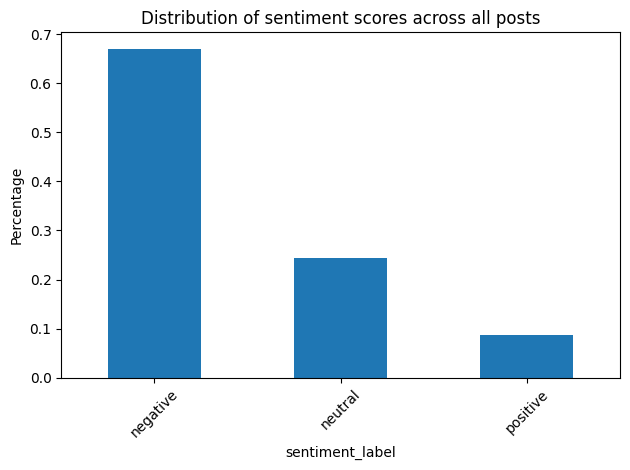

In [42]:
import matplotlib.pyplot as plt
sentiment_distribution.plot(kind="bar")
plt.ylabel("Percentage")
plt.title("Distribution of sentiment scores across all posts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [67]:
sentiment_descriptives["negative_prob"]["mean"]
sentiment_descriptives["neutral_prob"]["mean"]
sentiment_descriptives["positive_prob"]["mean"]

np.float64(0.10990650669384723)

In [65]:
mean_sentiment_scores_raw = df_sentiment[["negative_prob","neutral_prob","positive_prob"]].mean().sort_values(ascending=False)
mean_sentiment_scores = mean_sentiment_scores_raw.rename({"negative_prob":"negative","neutral_prob":"neutral","positive_prob":"positive"})
print(mean_sentiment_scores)

negative    0.573677
neutral     0.316417
positive    0.109907
dtype: float64


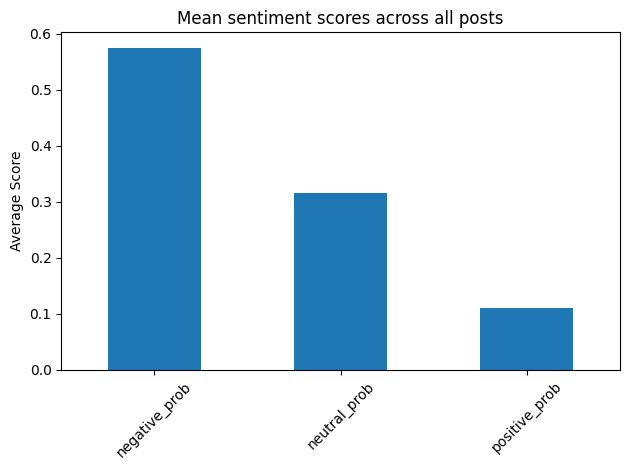

In [55]:
mean_sentiment_scores.plot(kind="bar")
plt.ylabel("Average Score")
plt.title("Mean sentiment scores across all posts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

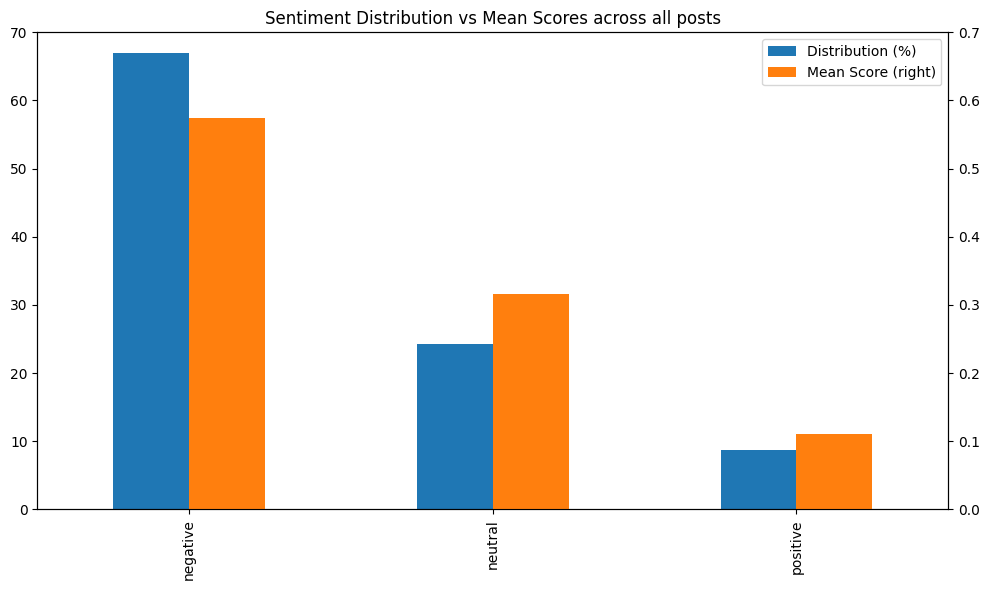

In [77]:
# Combine both into one dataframe
comparison_df = pd.DataFrame({
    "Distribution (%)": sentiment_distribution * 100,
    "Mean Score": mean_sentiment_scores
})

# Sort by distribution for consistency
comparison_df = comparison_df.sort_values("Distribution (%)", ascending=False)

# Plot
ax = comparison_df.plot(kind="bar", figsize=(10, 6), secondary_y="Mean Score")
plt.title("Sentiment Distribution vs Mean Scores across all posts")
plt.xlabel("Sentiment")
plt.xticks(rotation=45)
plt.tight_layout()
ax.right_ax.set_ylim(0,0.7)
ax.set_ylim(0,70)
plt.show()